In [33]:
import shutil
from pathlib import Path
shutil.rmtree("data/cache", ignore_errors=True)
Path("data/cache").mkdir()

In [22]:
import sys
sys.path.append('../')

from backend.ml.adapters.dataset_adapter import DatasetAdapter
from collections import Counter
import numpy as np

adapter_cwru = DatasetAdapter('../configs/datasets/cwru.yaml')
signals_cwru = adapter_cwru.load(
    '../data/raw/cwru/',
    use_cache=False
)

print(f"\nNombre de signaux : {len(signals_cwru)}")
print(f"Shape d'un signal : {signals_cwru[0].signals.shape}")
print(f"Sampling rate     : {signals_cwru[0].sampling_rate} Hz")

print("\nDistribution des classes :")
for label, count in Counter(s.label for s in signals_cwru).items():
    print(f"  {label:25s} : {count}")

  Chargement CWRU : 40 fichiers .mat...
  Stats calculées sur 4 fichiers normaux
  ✓ 100_3.mat       → sain (1010 fenêtres)
  ✓ 105_0.mat       → roulement_interne_faible (251 fenêtres)
  ✓ 106_1.mat       → roulement_interne_faible (253 fenêtres)
  ✓ 107_2.mat       → roulement_interne_faible (253 fenêtres)
  ✓ 108_3.mat       → roulement_interne_faible (255 fenêtres)
  ✓ 118_0.mat       → roulement_bille_faible (254 fenêtres)
  ✓ 119_1.mat       → roulement_bille_faible (251 fenêtres)
  ✓ 120_2.mat       → roulement_bille_faible (252 fenêtres)
  ✓ 121_3.mat       → roulement_bille_faible (252 fenêtres)
  ✓ 130_0.mat       → roulement_externe_faible (253 fenêtres)
  ✓ 131_1.mat       → roulement_externe_faible (254 fenêtres)
  ✓ 132_2.mat       → roulement_externe_faible (251 fenêtres)
  ✓ 133_3.mat       → roulement_externe_faible (254 fenêtres)
  ✓ 169_0.mat       → roulement_interne_moyen (252 fenêtres)
  ✓ 170_1.mat       → roulement_interne_moyen (252 fenêtres)
  ✓ 171_2.mat     

In [23]:
from backend.ml.features.feature_extractor import extract_features_per_window

print("Extraction par fenêtre individuelle...")
X_cwru, y_cwru, meta_cwru = extract_features_per_window(
    signals_cwru, verbose=True
)

print(f"\nShape X_cwru      : {X_cwru.shape}")
print(f"Exemples par classe :")
from collections import Counter
for label, count in sorted(Counter(y_cwru).items()):
    print(f"  {label:30s} : {count} fenêtres")

Extraction par fenêtre individuelle...
  Signal 0/40 — 100_3
  Signal 20/40 — 188_3

  Total : 12627 fenêtres extraites

Shape X_cwru      : (12627, 15)
Exemples par classe :
  roulement_bille_faible         : 1009 fenêtres
  roulement_bille_grave          : 1011 fenêtres
  roulement_bille_moyen          : 1011 fenêtres
  roulement_externe_faible       : 1012 fenêtres
  roulement_externe_grave        : 1013 fenêtres
  roulement_externe_moyen        : 1010 fenêtres
  roulement_interne_faible       : 1012 fenêtres
  roulement_interne_grave        : 1010 fenêtres
  roulement_interne_moyen        : 1008 fenêtres
  sain                           : 3531 fenêtres


In [24]:
import pandas as pd
import pickle
from pathlib import Path

# Vérification normalisation des features CWRU
print("Statistiques des features CWRU (doit être centré autour de 0) :")
df = pd.DataFrame(X_cwru)
print(f"  Moyenne globale : {df.values.mean():.4f}  (idéal : ≈ 0)")
print(f"  Std globale     : {df.values.std():.4f}   (idéal : ≈ 1)")
print(f"  Min             : {df.values.min():.4f}")
print(f"  Max             : {df.values.max():.4f}")

# Charger les features VBL sauvegardées depuis le notebook précédent
vbl_features_path = Path('../data/processed/X_vbl.npy')
if vbl_features_path.exists():
    X_vbl = np.load(vbl_features_path)
    print(f"\nFeatures VBL rechargées : {X_vbl.shape}")
    print(f"Features CWRU           : {X_cwru.shape}")
    print("\n=== Analyse compatibilité ===")
    print(f"VBL   : {X_vbl.shape[1]} features (3 canaux × 15)")
    print(f"CWRU  : {X_cwru.shape[1]} features ({X_cwru.shape[1]//15} canal × 15)")
    if X_cwru.shape[1] != X_vbl.shape[1]:
        print("⚠️  Espaces de features différents → modèles séparés par dataset")
    else:
        print("✅ Même espace — fusion possible")
else:
    print("\n⚠️  Fichier X_vbl.npy non trouvé. Exécute d'abord le notebook VBL avec sauvegarde.")

Statistiques des features CWRU (doit être centré autour de 0) :
  Moyenne globale : 173.5956  (idéal : ≈ 0)
  Std globale     : 695.8687   (idéal : ≈ 1)
  Min             : -0.9130
  Max             : 3787.5000

⚠️  Fichier X_vbl.npy non trouvé. Exécute d'abord le notebook VBL avec sauvegarde.


In [25]:
from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Grouper les FENÊTRES par fichier source
window_groups = defaultdict(list)
for i, m in enumerate(meta_cwru):
    window_groups[m['unit_id']].append(i)

print(f"Fichiers uniques    : {len(window_groups)}")
print(f"Fenêtres par fichier (exemple) :")
for fid, indices in list(window_groups.items())[:3]:
    print(f"  {fid:10s} → {len(indices)} fenêtres")

# Split par charge (test = charge 3 HP = fichiers se terminant par le 4ème)
# Les fichiers CWRU sont numérotés : 97,98,99,100 → charges 0,1,2,3 HP
# On sépare le dernier fichier de chaque groupe de 4 (charge 3 HP)

all_file_ids = sorted(window_groups.keys())

# Identifier la charge par position dans le groupe de 4
# 97→0HP, 98→1HP, 99→2HP, 100→3HP
# 105→0HP, 106→1HP, 107→2HP, 108→3HP, etc.
def get_charge(file_id):
    # file_id ex: "100_3" -> charge 3
    parts = file_id.split('_')
    if len(parts) >= 2:
        try:
            return int(parts[-1])
        except:
            pass
    # Fallback: essayer de convertir directement (si pas de underscore)
    try:
        num = int(file_id)
        # Anciennes plages (au cas où)
        if 97 <= num <= 100: return num - 97
        if 105 <= num <= 108: return num - 105
        if 118 <= num <= 121: return num - 118
        if 130 <= num <= 133: return num - 130
        if 169 <= num <= 172: return num - 169
        if 185 <= num <= 188: return num - 185
        if 197 <= num <= 200: return num - 197
        if 209 <= num <= 212: return num - 209
        if 222 <= num <= 225: return num - 222
        if 234 <= num <= 237: return num - 234
    except:
        pass
    return -1

# Train = charges 0,1,2 | Test = charge 3
train_files = [fid for fid in all_file_ids if get_charge(fid) < 3]
test_files  = [fid for fid in all_file_ids if get_charge(fid) == 3]

print(f"\nSplit par charge :")
print(f"  Train (charges 0,1,2) : {len(train_files)} fichiers")
print(f"  Test  (charge 3)      : {len(test_files)} fichiers")

train_idx = [i for fid in train_files for i in window_groups[fid]]
test_idx  = [i for fid in test_files  for i in window_groups[fid]]

X_train_cw = X_cwru[train_idx]
X_test_cw  = X_cwru[test_idx]
y_train_cw = [y_cwru[i] for i in train_idx]
y_test_cw  = [y_cwru[i] for i in test_idx]

print(f"  Train : {len(X_train_cw)} fenêtres")
print(f"  Test  : {len(X_test_cw)} fenêtres")

# Entraînement
rf_cwru = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_cwru.fit(X_train_cw, y_train_cw)
y_pred_cw = rf_cwru.predict(X_test_cw)
acc_cw    = accuracy_score(y_test_cw, y_pred_cw)

print(f"\nAccuracy CWRU (split par charge) : {acc_cw*100:.2f}%")
print()
print(classification_report(y_test_cw, y_pred_cw))

Fichiers uniques    : 40
Fenêtres par fichier (exemple) :
  100_3      → 1010 fenêtres
  105_0      → 251 fenêtres
  106_1      → 253 fenêtres

Split par charge :
  Train (charges 0,1,2) : 30 fichiers
  Test  (charge 3)      : 10 fichiers
  Train : 9339 fenêtres
  Test  : 3288 fenêtres

Accuracy CWRU (split par charge) : 96.02%

                          precision    recall  f1-score   support

  roulement_bille_faible       1.00      1.00      1.00       252
   roulement_bille_grave       0.82      1.00      0.90       253
   roulement_bille_moyen       0.77      1.00      0.87       253
roulement_externe_faible       1.00      1.00      1.00       254
 roulement_externe_grave       1.00      1.00      1.00       253
 roulement_externe_moyen       1.00      0.75      0.86       253
roulement_interne_faible       1.00      1.00      1.00       255
 roulement_interne_grave       1.00      1.00      1.00       253
 roulement_interne_moyen       0.99      0.73      0.84       252
        

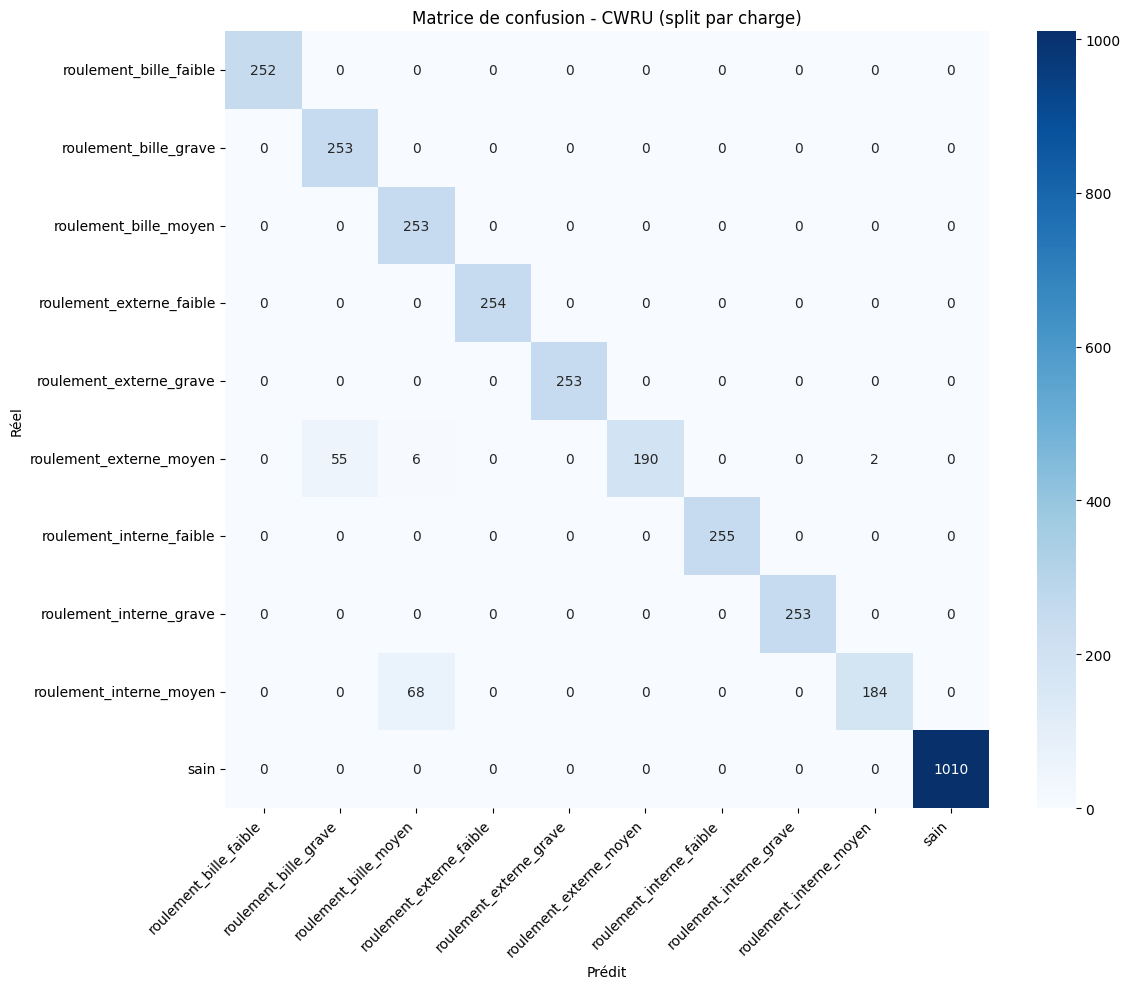

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_cw, y_pred_cw, labels=rf_cwru.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_cwru.classes_, yticklabels=rf_cwru.classes_)
plt.title('Matrice de confusion - CWRU (split par charge)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

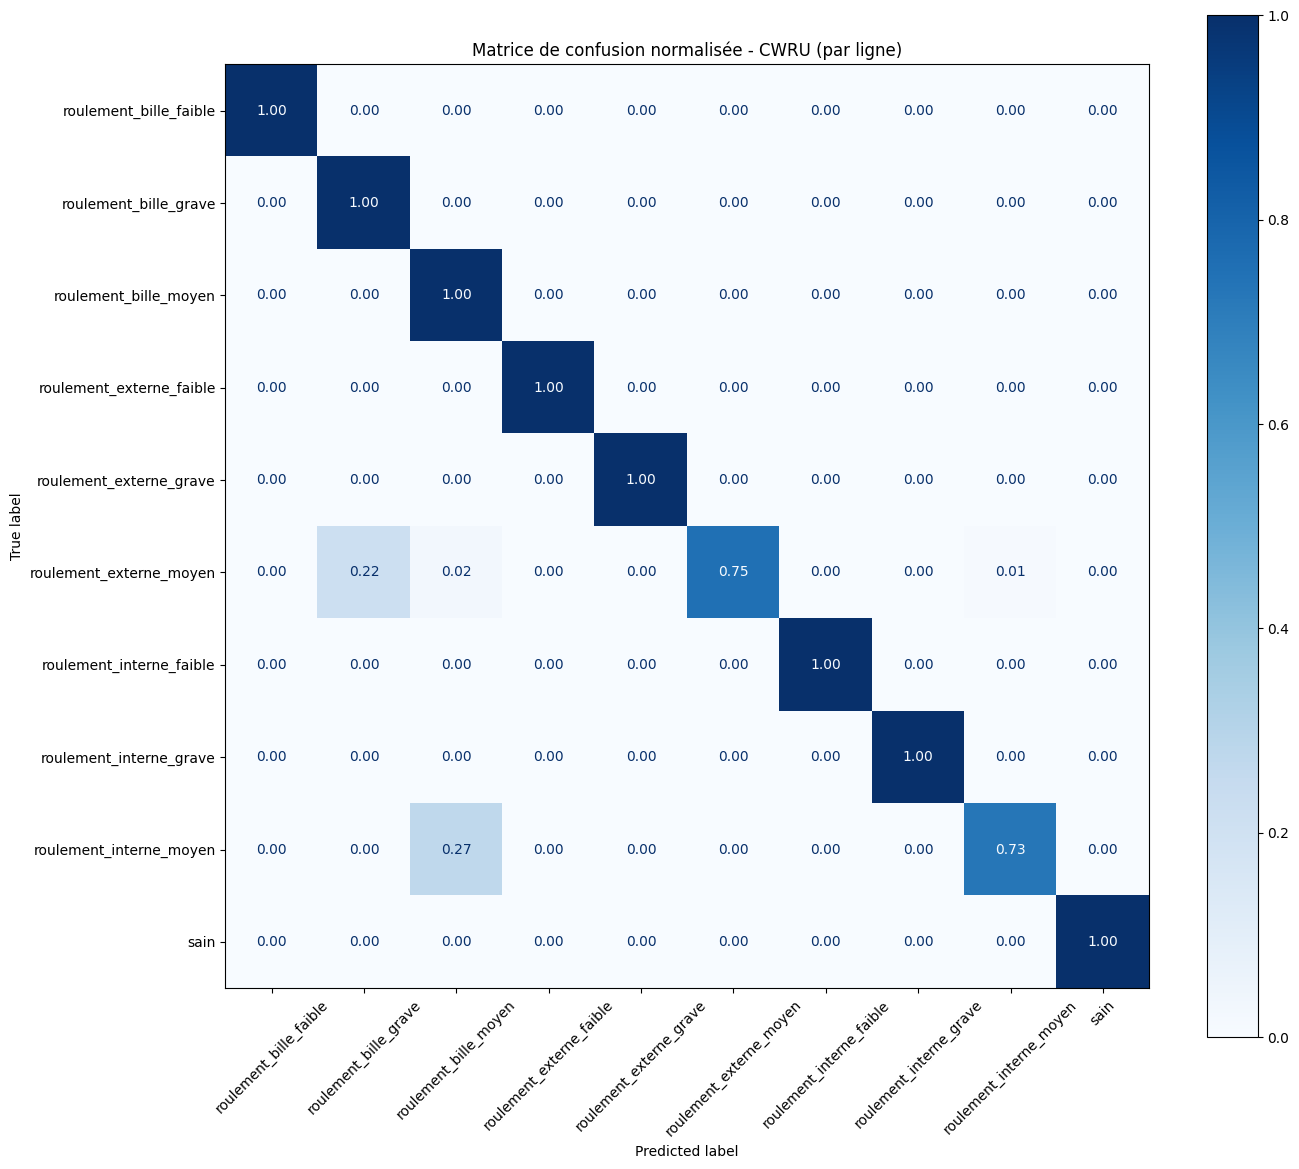

In [13]:
# Normalisation par ligne (pourcentage)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=rf_cwru.classes_)
fig, ax = plt.subplots(figsize=(14, 12))
disp_norm.plot(ax=ax, xticks_rotation=45, cmap='Blues', values_format='.2f')
ax.set_title('Matrice de confusion normalisée - CWRU (par ligne)')
plt.tight_layout()
plt.show()

In [11]:
print("=" * 50)
print("BILAN CWRU")
print("=" * 50)
print(f"Fichiers chargés    : {len(signals_cwru)}")
print(f"Accuracy Random Forest : {acc_cw*100:.2f}%")
print(f"Features par signal : {X_cwru.shape[1]}")
print()
print("Classes :")
for label, count in Counter(y_cwru).items():
    print(f"  {label:25s} : {count} signaux")

BILAN CWRU
Fichiers chargés    : 40
Accuracy Random Forest : 96.02%
Features par signal : 15

Classes :
  sain                      : 3531 signaux
  roulement_interne_faible  : 1012 signaux
  roulement_bille_faible    : 1009 signaux
  roulement_externe_faible  : 1012 signaux
  roulement_interne_moyen   : 1008 signaux
  roulement_bille_moyen     : 1011 signaux
  roulement_externe_moyen   : 1010 signaux
  roulement_interne_grave   : 1010 signaux
  roulement_bille_grave     : 1011 signaux
  roulement_externe_grave   : 1013 signaux


In [27]:
import numpy as np
import pickle

np.save('../data/processed/X_cwru.npy', X_cwru)
with open('../data/processed/y_cwru.pkl', 'wb') as f:
    pickle.dump(y_cwru, f)
with open('../data/processed/meta_cwru.pkl', 'wb') as f:
    pickle.dump(meta_cwru, f)

print("✅ Features CWRU sauvegardées")
print(f"   X_cwru : {X_cwru.shape}")

✅ Features CWRU sauvegardées
   X_cwru : (12627, 15)


In [36]:
import zipfile
from pathlib import Path
from collections import defaultdict

zip_path = Path(r"C:\Users\HP PRO\Desktop\souley\ecole\S8\Maintenance\Projet\data\raw\mcc5_thu\MCC5-THU gearbox fault diagnosis datasets.zip")
prefixes = defaultdict(set)

with zipfile.ZipFile(zip_path, 'r') as z:
    for name in z.namelist():
        if name.endswith('/') or '__MACOSX' in name or name.startswith('._') or not name.endswith('.csv'):
            continue
        filename = Path(name).name
        parts = filename.split('_')
        # On prend jusqu'à 4 premiers segments pour couvrir "teeth_break_and_bearing"
        max_len = min(4, len(parts))
        for n in range(2, max_len+1):
            key = '_'.join(parts[:n])
            prefixes[key].add(filename)

print("Préfixes distincts (2 à 4 segments) :")
for p in sorted(prefixes.keys(), key=lambda x: (len(x), x)):
    print(f"  {p} : {len(prefixes[p])} fichiers")
    exemple = next(iter(prefixes[p]))
    print(f"      Ex : {exemple}")

Préfixes distincts (2 à 4 segments) :
  gear_wear : 36 fichiers
      Ex : gear_wear_L_speed_circulation_20Nm-2000rpm.csv
  miss_teeth : 12 fichiers
      Ex : miss_teeth_torque_circulation_3000rpm_20Nm.csv
  gear_wear_H : 12 fichiers
      Ex : gear_wear_H_speed_circulation_10Nm-2000rpm.csv
  gear_wear_L : 12 fichiers
      Ex : gear_wear_L_speed_circulation_20Nm-2000rpm.csv
  gear_wear_M : 12 fichiers
      Ex : gear_wear_M_speed_circulation_10Nm-1000rpm.csv
  teeth_break : 108 fichiers
      Ex : teeth_break_L_speed_circulation_20Nm-3000rpm.csv
  teeth_crack : 36 fichiers
      Ex : teeth_crack_H_torque_circulation_3000rpm_10Nm.csv
  gear_pitting : 36 fichiers
      Ex : gear_pitting_M_torque_circulation_2000rpm_20Nm.csv
  health_speed : 6 fichiers
      Ex : health_speed_circulation_20Nm-2000rpm.csv
  health_torque : 6 fichiers
      Ex : health_torque_circulation_2000rpm_10Nm.csv
  teeth_break_H : 12 fichiers
      Ex : teeth_break_H_torque_circulation_2000rpm_20Nm.csv
  teeth_bre